<a href="https://colab.research.google.com/github/MANI-WEBDEVE/Learn_AI/blob/main/machine_learning/unsupervised_ML/KMeans_Algorithm/KMeans_Cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# create the data point through numpy array
X = np.array([[1,2], [2,1], [4,5], [5,4], [8,8], [9,9], [10,3],[12, 11], [15,1], [1,14]])
scaler=StandardScaler()
X_scaler=scaler.fit_transform(X) # normalize the data points




In [8]:
k_means_model=KMeans(
    n_clusters=2,      # K value
    init='k-means++',  # Better than random initialization
    n_init=10,         # 10 baar try karega, best result lega
    max_iter=300,      # Max iterations
    random_state=42    # Reproducible results
)

k_means_model.fit(X_scaler)

KMeans(n_clusters=2, n_init=10, random_state=42)

In [9]:
print("Centroids:", k_means_model.cluster_centers_)
print("Labels:", k_means_model.labels_)  # Har point ka cluster number
print("WCSS:", k_means_model.inertia_)   # Total squared distance

Centroids: [[ 0.89025316  0.14079698]
 [-0.89025316 -0.14079698]]
Labels: [1 1 1 1 0 0 0 0 0 1]
WCSS: 11.876255278139517


In [10]:
# Centroids: [[-0.62985817 -0.62985817]
#  [ 1.25971634  1.25971634]]
# Labels: [0 0 0 0 1 1]
# WCSS: 2.4786885245901633

--------------------
2
--------------------
3
--------------------
2
--------------------
3
--------------------
2
--------------------
2
--------------------
2
--------------------
2
--------------------
2
--------------------
1


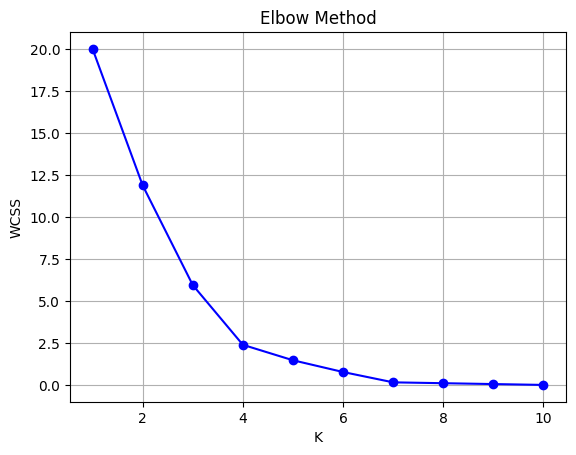

In [11]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaler)
    wcss.append(km.inertia_)
    # print( km.inertia_)
    print('--------------------')
    print(km.n_iter_)

plt.plot(range(1,11), wcss, 'bo-')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

### Code From Scratch how its works

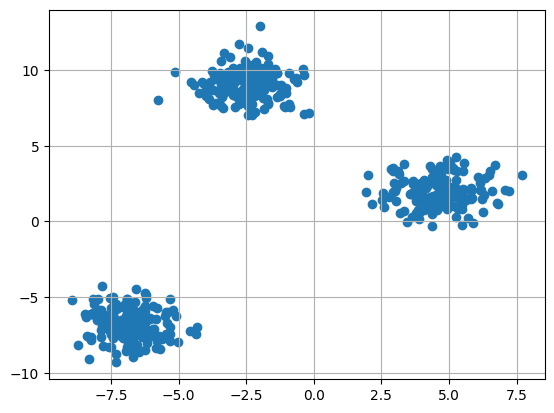

In [12]:
# First import the library and dataset

X, Y = make_blobs(n_samples=500, n_features=2, centers=3, random_state=42)
plt.grid(True)
plt.scatter(X[:,0], X[:,1])
plt.show()

In [13]:
X.shape

(500, 2)

In [14]:
Y.shape

(500,)

intilizing the centeroid to main concept of K Means cluster

In [15]:
k =3
np.random.seed(23)
clusters={} # empty dictionary

for idx in range(k):
  center=2*(2*np.random.random((X.shape[1],)) -1)
  ponits=[]
  cluster={
      'center':center,
      'ponits': []
  }


  clusters[idx]=cluster


In [16]:
for i in range(k):
  print(i)

0
1
2


In [17]:
clusters

{0: {'center': array([0.06919154, 1.78785042]), 'ponits': []},
 1: {'center': array([ 1.06183904, -0.87041662]), 'ponits': []},
 2: {'center': array([-1.11581855,  0.74488834]), 'ponits': []}}

In [18]:
X.shape[1]

2

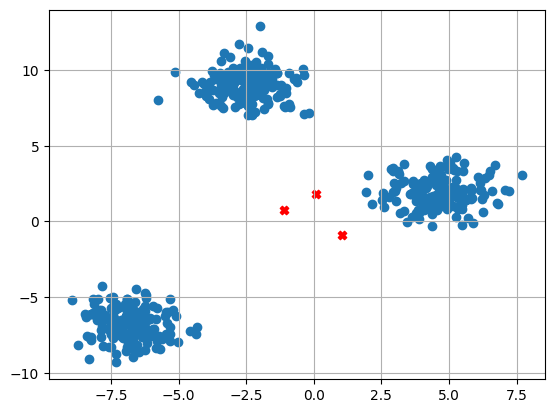

In [19]:
plt.scatter(X[:,0], X[:,1])
plt.grid(True)

for i in clusters:
  center=clusters[i]['center']
  plt.scatter(center[0], center[1], marker='X', c='red')


### Defining Euclidean Distance

In [20]:
def euclidean_distance(p1,p2):
  return np.sqrt(np.sum(p1-p2)**2)

### Assign the cluster

In [21]:
def assign_clusters(X, clusters):
    for idx in range(X.shape[0]): # shape means (number of data points, features)
                                                       # 500               2        example only
        dist = []

        curr_x = X[idx]           #  X[2] = 34 , X[4] = 400  example to store the current data point to loop interation

        for i in range(k):  # you remeber intialize the centroid point to define the  K value

            dis = euclidean_distance(curr_x,clusters[i]['center'])  # calculate the distance each data point to cluster center / cluster[center] means = [0.0987, 9.987]
            dist.append(dis)
        curr_cluster = np.argmin(dist)
        clusters[curr_cluster]['points'].append(curr_x)
    return clusters

In [30]:
for i in range(k):
  print(clusters[i]['center'])

[0.06919154 1.78785042]
[ 1.06183904 -0.87041662]
[-1.11581855  0.74488834]


In [31]:
for i in range(k):
  print(euclidean_distance( [-0.87678632,  7.58414475],clusters[i]['center']))

4.850316479354386
6.515936016543922
7.078288636003522


In [28]:
X

array([[-5.73035386, -7.58328602],
       [ 1.94299219,  1.91887482],
       [ 6.82968177,  1.1648714 ],
       [-2.90130578,  7.55077118],
       [ 5.84109276,  1.56509431],
       [ 5.47021465,  1.11708586],
       [-4.31954265, -6.97616949],
       [ 4.91033566,  1.92293157],
       [ 3.57225841,  1.8307902 ],
       [-7.50444577, -6.85401854],
       [ 3.99330595,  0.89162168],
       [-1.35060204,  8.19360381],
       [-0.37616425,  7.06219833],
       [-1.93830711, 10.14985177],
       [ 4.92965369,  4.04857048],
       [ 5.69830332,  0.2144302 ],
       [-2.58120774, 10.01781903],
       [-8.00234921, -6.49769985],
       [-6.7973432 , -5.81462922],
       [-3.6155326 ,  7.8180795 ],
       [ 3.24131126,  2.53613892],
       [-2.30033403,  7.054616  ],
       [ 5.2164358 ,  2.28441984],
       [-5.31410316, -6.94585985],
       [-7.32606081, -6.6860196 ],
       [ 5.03433098,  1.5521852 ],
       [ 4.38490162,  3.47716267],
       [-6.09382703, -6.45465203],
       [-6.61257693,